# Multicoordinate Wave Project

## Authors: NRPy tutorial maintainers

To run the whole notebook, click the `>>` toolbar button and choose
**Restart Kernel and Run All Cells...**.

This notebook generates one scalar-wave project containing several coordinate
options, then validates that each option has its own RHS source and diagnostic
output.

**Notebook Status:** Validated executable project tutorial. The maintainer
author credit is used because this notebook has no direct predecessor in the
frozen tutorial corpus with a recoverable author line.

**Validation Notes:** The validation section checks one diagnostic file per
coordinate option against the trusted exact solution using sampled pointwise
relative-error tolerances.

Navigation: [Index](../index.ipynb) |
Previous: [GeneralRFM and Fisheye Coordinates](../4-curvilinear/generalrfm_and_fisheye.ipynb) |
Next: [BHaH Project Anatomy](../5-infrastructures/bhah_project_anatomy.ipynb)

# Table of Contents

1. [Required Reading and Source Code](#Required-Reading-and-Source-Code)
1. [Words for This Notebook](#Words-for-This-Notebook)
1. [Initial-Value Problem and Coordinate Options](#Initial-Value-Problem-and-Coordinate-Options)
1. [Workspace and Generated Files](#Workspace-and-Generated-Files)
1. [Step 1: Import Project Execution Helpers](#Step-1:-Import-Project-Execution-Helpers)
1. [Step 2: Generate the Multicoordinate Project](#Step-2:-Generate-the-Multicoordinate-Project)
1. [Step 3: Inspect Coordinate-Specific Artifacts](#Step-3:-Inspect-Coordinate-Specific-Artifacts)
1. [Step 4: Build and Run the Shared Executable](#Step-4:-Build-and-Run-the-Shared-Executable)
1. [Validation Check](#Validation-Check)
1. [Step 5: Plot Multicoordinate Diagnostics](#Step-5:-Plot-Multicoordinate-Diagnostics)
1. [What next?](#What-next?)

# Required Reading and Source Code
### [Back to [top](#Table-of-Contents)]

Required reading:

- [Curvilinear Wave Equation](wave_equation_curvilinear.ipynb)
- [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)
- [GeneralRFM and Fisheye Coordinates](../4-curvilinear/generalrfm_and_fisheye.ipynb)

Installed NRPy modules used here:

- `nrpy.examples.wave_equation_multicoordinates`
  (`examples/wave_equation_multicoordinates.py`): generates the
  multicoordinate project.
- `nrpy.equations.wave_equation.WaveEquationCurvilinear_RHSs`
  (`equations/wave_equation/WaveEquationCurvilinear_RHSs.py`): builds each
  coordinate-specific RHS.
- `nrpy.infrastructures.BHaH.wave_equation.rhs_eval`
  (`infrastructures/BHaH/wave_equation/rhs_eval.py`): registers generated
  wave RHS functions.
- `nrpy.infrastructures.BHaH.diagnostics.diagnostics`
  (`infrastructures/BHaH/diagnostics/diagnostics.py`): provides diagnostics
  infrastructure.
- `nrpy.infrastructures.BHaH.CurviBoundaryConditions.register_all`
  (`infrastructures/BHaH/CurviBoundaryConditions/register_all.py`):
  generates curvilinear boundary-condition files.

These are package-relative paths inside the pip-installed `nrpy`; no cloned
source checkout is required.

# Words for This Notebook
### [Back to [top](#Table-of-Contents)]

- **`u`:** the scalar wave amplitude.
- **`v`:** the auxiliary time derivative `v = partial_t u`.
- **Wave speed:** the propagation speed used by every coordinate option.
- **Coordinate option:** one grid/reference-metric choice available inside the
  same generated project.
- **Coordinate-specific source:** generated C code for one coordinate option.
- **Shared executable:** one compiled program that runs all coordinate options.
- **Runtime parameter:** a value chosen at run time without regenerating code.
- **Diagnostic file:** a text file containing sampled numerical-vs-exact data.
- **BHaH:** NRPy's standalone generated-code infrastructure.
- **Method of Lines:** the time-stepping approach used by the executable.
- **Ghost zone:** exterior grid points used by finite-difference stencils and
  boundary fills.
- **Generated artifact:** a source, metadata, runtime, or diagnostic file
  produced by the notebook workflow.

# Initial-Value Problem and Coordinate Options
### [Back to [top](#Table-of-Contents)]

All coordinate options solve the same scalar wave equation,

$$
\partial_t^2 u = c^2 \nabla^2 u,
\qquad v = \partial_t u.
$$

The project initializes a trusted exact wave, evolves `u` and `v` with Method
of Lines time stepping, fills ghost zones with generated boundary code, and
writes sampled relative-error diagnostics. What changes between coordinate
options is the coordinate map and RHS source file; the executable, parameter
file, time-stepping infrastructure, and validation logic are shared.

| Coordinate | Purpose | What changes |
| --- | --- | --- |
| `Cartesian` | baseline straight grid | Cartesian RHS directory and diagnostic |
| `Spherical` | standard spherical grid | angular coordinate geometry |
| `SinhCartesian` | stretched Cartesian grid | stretched coordinate source |
| `SinhSpherical` | stretched spherical grid | stretched spherical source and diagnostic |

# Workspace and Generated Files
### [Back to [top](#Table-of-Contents)]

This notebook owns `project/wave_equation_multicoordinates` relative to the
`3-wave_equation` notebook directory. Each run regenerates that directory only
if it contains `.nrpy_tutorial_owned`; otherwise the notebook stops to protect
user files.

| Artifact | Role | Where used |
| --- | --- | --- |
| `.nrpy_tutorial_owned` | ownership marker | regeneration guard |
| `wave_equation_multicoordinates.par` | shared runtime settings | run and validation |
| `<Coordinate>/rhs_eval__rfm__<Coordinate>.c` | coordinate RHS | source metadata |
| `bcstruct_set_up.c` and `apply_bcs_*.c` | boundary handling | executable |
| `MoL/` files | time stepping | executable |
| `diagnostics/` files | diagnostic writers | validation |
| `BHaH_function_prototypes.h` | declarations | source metadata |
| `out0d-grid*-<Coordinate>-*.txt` | diagnostics | validation and plot |

Inspect the marker slug/generator, coordinate list, output cadence, one RHS
per coordinate, boundary setup and fills, shared RK updates, diagnostic files,
prototypes, and one output file per coordinate.

# Step 1: Import Project Execution Helpers
### [Back to [top](#Table-of-Contents)]

Skim these helper cells on a first pass. They guard the generated project,
inspect generated files, run commands, and parse diagnostics.

In [1]:
from pathlib import Path
import hashlib
import math
import re
import shutil
import subprocess
import sys


PROJECT_ROOT = Path.cwd()
NOTEBOOK_NAME = "wave_equation_multicoordinates.ipynb"
GENERATOR_MODULE = "nrpy.examples.wave_equation_multicoordinates"
WARNING_RE = re.compile(r"(^|: )warning:", re.IGNORECASE)
FUNCTION_RE = re.compile(
    r"^(?:static\s+)?(?:void|int|REAL|bool)\s+([A-Za-z_][A-Za-z0-9_]*)\s*\(",
    re.MULTILINE,
)

In [2]:
def display_path(path):
    return Path(path).resolve().relative_to(PROJECT_ROOT.resolve())


def clean_command_output(text):
    return (text or "").replace(str(PROJECT_ROOT), "<notebook-dir>")


def command_has_warning(text):
    for line in (text or "").splitlines():
        stripped = line.strip()
        if stripped.startswith("WARNING:") or WARNING_RE.search(stripped):
            return True
    return False


def run_command(args, cwd, timeout):
    try:
        result = subprocess.run(
            args,
            cwd=cwd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=False,
            timeout=timeout,
        )
    except FileNotFoundError as exc:
        raise RuntimeError(f"Required command is missing: {args[0]}") from exc
    output = clean_command_output(result.stdout)
    if result.returncode != 0:
        print(output)
        raise RuntimeError(f"Command failed: {' '.join(map(str, args))}")
    if command_has_warning(output):
        print(output)
        raise RuntimeError(f"Command emitted warning output: {args}")
    return output

In [3]:
def require_toolchain():
    if shutil.which("make") is None:
        raise RuntimeError("This notebook requires make.")
    if not any(shutil.which(name) for name in ["cc", "gcc", "clang"]):
        raise RuntimeError("This notebook requires a C compiler.")


def replace_once(text, old, new, label):
    count = text.count(old)
    if count != 1:
        raise RuntimeError(f"Expected one {label} setting; found {count}.")
    print("updated runtime setting:", label)
    return text.replace(old, new, 1)


def print_markdown_table(headers, rows):
    print("| " + " | ".join(headers) + " |")
    print("| " + " | ".join("---" for _ in headers) + " |")
    for row in rows:
        print("| " + " | ".join(str(value) for value in row) + " |")

In [4]:
def prepare_owned_project(project_dir, marker_text):
    marker = project_dir / ".nrpy_tutorial_owned"
    existed = project_dir.exists()
    print("project path:", display_path(project_dir))
    print("directory existed before generation:", existed)
    print("cleanup policy: guarded delete and regenerate")
    if existed and not marker.is_file():
        raise RuntimeError(
            f"{display_path(project_dir)} exists without .nrpy_tutorial_owned."
        )
    if existed:
        shutil.rmtree(project_dir)
    project_dir.parent.mkdir(parents=True, exist_ok=True)
    return marker_text


def write_ownership_marker(project_dir, marker_text):
    marker = project_dir / ".nrpy_tutorial_owned"
    marker.write_text(marker_text, encoding="utf-8")
    print("ownership marker:", marker.relative_to(project_dir))

In [5]:
def source_metadata(path):
    text = path.read_text(encoding="utf-8", errors="replace")
    digest = hashlib.sha256(text.encode("utf-8")).hexdigest()[:12]
    functions = ", ".join(FUNCTION_RE.findall(text)) or "none found"
    return [path.relative_to(PROJECT_DIR), path.stat().st_size, digest, functions]


def diagnostic_rows_from_file(path):
    return [
        [float(value) for value in line.split()]
        for line in path.read_text(encoding="utf-8", errors="replace").splitlines()
        if line.strip() and not line.lstrip().startswith("#")
    ]

# Step 2: Generate the Multicoordinate Project
### [Back to [top](#Table-of-Contents)]

The next cells print the stable project path and cleanup policy, run the
generator, then shorten runtime-only parameters for notebook execution.

In [6]:
PROJECT_NAME = "wave_equation_multicoordinates"
PROJECT_DIR = PROJECT_ROOT / "project" / PROJECT_NAME
EXPECTED_COORDINATES = {"Cartesian", "Spherical", "SinhCartesian", "SinhSpherical"}
MARKER_TEXT = (
    f"owned_by = {NOTEBOOK_NAME}\n"
    f"generator = python -m {GENERATOR_MODULE}\n"
    "policy = this tutorial may delete and regenerate this directory\n"
)
prepare_owned_project(PROJECT_DIR, MARKER_TEXT)

project path: project/wave_equation_multicoordinates
directory existed before generation: True
cleanup policy: guarded delete and regenerate


'owned_by = wave_equation_multicoordinates.ipynb\ngenerator = python -m nrpy.examples.wave_equation_multicoordinates\npolicy = this tutorial may delete and regenerate this directory\n'

In [7]:
command = [sys.executable, "-m", GENERATOR_MODULE]
print("generator command:", "python -m", GENERATOR_MODULE)
generator_output = run_command(command, PROJECT_ROOT, timeout=300)
print(generator_output.rstrip())
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(PROJECT_DIR)
write_ownership_marker(PROJECT_DIR, MARKER_TEXT)

generator command: python -m nrpy.examples.wave_equation_multicoordinates


In 0.035s, worker completed task '_register_CFunction_diagnostics'
In 0.035s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.036s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_and_z_axes'
In 0.041s, worker completed task 'register_CFunction_initial_data'
In 0.039s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.042s, worker completed task 'register_CFunction_diagnostics_nearest_2d_xy_and_yz_planes'
In 0.042s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_and_z_axes'
In 0.042s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.044s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.042s, worker completed task 'register_CFunction_diagnostics_nearest'
In 0.046s, worker completed task 'register_CFunction_diagnostics_nearest_2d_xy_and_yz_planes'
In 0.046s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_an

In [8]:
parfile = PROJECT_DIR / "wave_equation_multicoordinates.par"
par_text = parfile.read_text(encoding="utf-8")
par_text = replace_once(par_text, "t_final = 8.0", "t_final = 0.2", "final time")
par_text = replace_once(
    par_text,
    "diagnostics_output_every = 0.2",
    "diagnostics_output_every = 0.1",
    "diagnostic output interval",
)
par_text = replace_once(
    par_text,
    "output_progress_every = 1",
    "output_progress_every = 1000000",
    "progress output interval",
)
parfile.write_text(par_text, encoding="utf-8")

updated runtime setting: final time
updated runtime setting: diagnostic output interval
updated runtime setting: progress output interval


1474

# Step 3: Inspect Coordinate-Specific Artifacts
### [Back to [top](#Table-of-Contents)]

The inventory is complete for pre-build files. The metadata table then checks
that every coordinate option has exactly one RHS source file.

In [9]:
prebuild_files = sorted(
    path.relative_to(PROJECT_DIR)
    for path in PROJECT_DIR.rglob("*")
    if path.is_file()
)
print("complete pre-build generated-file inventory:")
for relative_path in prebuild_files:
    print(relative_path)
print("pre-build file count:", len(prebuild_files))

complete pre-build generated-file inventory:
.nrpy_tutorial_owned
BHaH_defines.h
BHaH_function_prototypes.h
Cartesian/apply_bcs_outerradiation_and_inner__rfm__Cartesian.c
Cartesian/bcstruct_set_up__rfm__Cartesian.c
Cartesian/ds_min_single_pt__rfm__Cartesian.c
Cartesian/numerical_grid_params_Nxx_dxx_xx__rfm__Cartesian.c
Cartesian/rfm_precompute_defines__rfm__Cartesian.c
Cartesian/rfm_precompute_free__rfm__Cartesian.c
Cartesian/rfm_precompute_malloc__rfm__Cartesian.c
Cartesian/rhs_eval__rfm__Cartesian.c
Cartesian/xx_to_Cart__rfm__Cartesian.c
Makefile
MoL/MoL_free_intermediate_stage_gfs.c
MoL/MoL_malloc_intermediate_stage_gfs.c
MoL/MoL_step_forward_in_time.c
SinhCartesian/apply_bcs_outerradiation_and_inner__rfm__SinhCartesian.c
SinhCartesian/bcstruct_set_up__rfm__SinhCartesian.c
SinhCartesian/ds_min_single_pt__rfm__SinhCartesian.c
SinhCartesian/numerical_grid_params_Nxx_dxx_xx__rfm__SinhCartesian.c
SinhCartesian/rfm_precompute_defines__rfm__SinhCartesian.c
SinhCartesian/rfm_precompute_fre

In [10]:
coordinate_dirs = {
    path.name
    for path in PROJECT_DIR.iterdir()
    if path.is_dir() and path.name not in {"MoL", "diagnostics", "intrinsics"}
}
missing_dirs = EXPECTED_COORDINATES.difference(coordinate_dirs)
if missing_dirs:
    raise RuntimeError(f"Missing coordinate directories: {sorted(missing_dirs)}")
coordinate_rhs_paths = {}
for coordinate in sorted(EXPECTED_COORDINATES):
    matches = sorted((PROJECT_DIR / coordinate).glob("rhs_eval*.c"))
    if len(matches) != 1:
        raise RuntimeError(f"Expected one RHS source for {coordinate}.")
    coordinate_rhs_paths[coordinate] = matches[0]
print("PASS: every coordinate option has one RHS source file.")

PASS: every coordinate option has one RHS source file.


In [11]:
print_markdown_table(
    ["coordinate", "RHS source", "bytes", "sha256 prefix", "function names"],
    [
        [coordinate] + source_metadata(path)
        for coordinate, path in sorted(coordinate_rhs_paths.items())
    ],
)

| coordinate | RHS source | bytes | sha256 prefix | function names |
| --- | --- | --- | --- | --- |
| Cartesian | Cartesian/rhs_eval__rfm__Cartesian.c | 5434 | 3f0e7c1866fb | rhs_eval_host, rhs_eval__rfm__Cartesian |
| SinhCartesian | SinhCartesian/rhs_eval__rfm__SinhCartesian.c | 8352 | 090c71def5ff | rhs_eval_host, rhs_eval__rfm__SinhCartesian |
| SinhSpherical | SinhSpherical/rhs_eval__rfm__SinhSpherical.c | 8140 | 7ba1ce7b8b04 | rhs_eval_host, rhs_eval__rfm__SinhSpherical |
| Spherical | Spherical/rhs_eval__rfm__Spherical.c | 7519 | dcfa9b6ea155 | rhs_eval_host, rhs_eval__rfm__Spherical |


In [12]:
print("--- wave_equation_multicoordinates.par ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))

--- wave_equation_multicoordinates.par ---
#### wave_equation_multicoordinates BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquationCurvilinear_RHSs
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.CurviBoundaryConditions.register_all
outer_bc_type = "radiation"     # (char[50])
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.2                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.checkpointing
checkpoint_every =

# Step 4: Build and Run the Shared Executable
### [Back to [top](#Table-of-Contents)]

One executable runs all coordinate options. The build summary proves successful
compilation; the complete build log is printed only if a failure or warning
occurs.

In [13]:
require_toolchain()
build_output = run_command(["make", "-j2"], PROJECT_DIR, timeout=300)
executable = PROJECT_DIR / PROJECT_NAME
if not executable.is_file():
    raise FileNotFoundError(executable)
c_source_count = len(list(PROJECT_DIR.rglob("*.c")))
object_count = len(list(PROJECT_DIR.rglob("*.o")))
build_line_count = len([line for line in build_output.splitlines() if line.strip()])
print_markdown_table(
    ["field", "value"],
    [
        ["command", "make -j2"],
        ["project", display_path(PROJECT_DIR)],
        ["return status", 0],
        ["executable", executable.relative_to(PROJECT_DIR)],
        ["C source count", c_source_count],
        ["object file count", object_count],
        ["build output line count", build_line_count],
    ],
)

| field | value |
| --- | --- |
| command | make -j2 |
| project | project/wave_equation_multicoordinates |
| return status | 0 |
| executable | wave_equation_multicoordinates |
| C source count | 81 |
| object file count | 81 |
| build output line count | 82 |


In [14]:
run_output = run_command([f"./{PROJECT_NAME}", "2.0"], PROJECT_DIR, timeout=120)
print("complete run output (convergence factor 2.0):")
print(run_output.rstrip() or "<no output>")

complete run output (convergence factor 2.0):
It: 0 t=0.000 / 0.2 = 0.00% dt=1/483.7 | t/h=0.00 ETA 0h00m00s
WRITING CHECKPOINT: cd struct size = 168 time=0.000000e+00
FINISHED WRITING CHECKPOINT


# Validation Check
### [Back to [top](#Table-of-Contents)]

The trusted reference is the exact wave solution in each diagnostic writer.
Each coordinate option must write exactly one diagnostic file. The error metric
is sampled pointwise absolute relative error in `u` and `v`.

In [15]:
EXPECTED_DIAGNOSTIC_COLUMNS = 5
MAX_ABS_UU_RELERROR = 1.0e-5
MAX_ABS_VV_RELERROR = 1.0e-3
diagnostics = sorted(PROJECT_DIR.glob("out0d-grid*.txt"))
if not diagnostics:
    raise FileNotFoundError("No diagnostic files were produced.")
diagnostic_by_coordinate = {}
for coordinate in sorted(EXPECTED_COORDINATES):
    matches = [path for path in diagnostics if f"-{coordinate}-" in path.name]
    if len(matches) != 1:
        raise RuntimeError(f"Expected one diagnostic file for {coordinate}.")
    diagnostic_by_coordinate[coordinate] = matches[0]

In [16]:
diagnostic_rows = {}
validation_rows = []
for coordinate, diagnostic in sorted(diagnostic_by_coordinate.items()):
    rows = diagnostic_rows_from_file(diagnostic)
    if len(rows) < 2:
        raise RuntimeError(f"Expected at least two rows in {diagnostic.name}.")
    for row in rows:
        if len(row) != EXPECTED_DIAGNOSTIC_COLUMNS:
            raise RuntimeError(f"Expected five columns in {diagnostic.name}.")
    final_row = rows[-1]
    abs_u_error = abs(final_row[1])
    abs_v_error = abs(final_row[2])
    if not math.isfinite(abs_u_error) or not math.isfinite(abs_v_error):
        raise RuntimeError(f"Expected finite errors in {diagnostic.name}.")
    passed = abs_u_error <= MAX_ABS_UU_RELERROR and abs_v_error <= MAX_ABS_VV_RELERROR
    validation_rows.append(
        [
            coordinate,
            coordinate_rhs_paths[coordinate].relative_to(PROJECT_DIR),
            diagnostic.name,
            final_row[0],
            f"{abs_u_error:.6e}",
            f"{abs_v_error:.6e}",
            MAX_ABS_UU_RELERROR,
            MAX_ABS_VV_RELERROR,
            "PASS" if passed else "FAIL",
        ]
    )
    if not passed:
        raise RuntimeError(f"Diagnostic tolerance failed for {diagnostic.name}.")
    diagnostic_rows[diagnostic] = rows

In [17]:
print_markdown_table(
    [
        "coordinate",
        "RHS source",
        "diagnostic",
        "final sampled time",
        "abs relative u error",
        "abs relative v error",
        "u tolerance",
        "v tolerance",
        "status",
    ],
    validation_rows,
)
print("PASS: all coordinate diagnostics satisfy the tolerance check.")

| coordinate | RHS source | diagnostic | final sampled time | abs relative u error | abs relative v error | u tolerance | v tolerance | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Cartesian | Cartesian/rhs_eval__rfm__Cartesian.c | out0d-grid00-Cartesian-conv_factor-2.00.txt | 0.099235273881392 | 1.001377e-09 | 1.219801e-06 | 1e-05 | 0.001 | PASS |
| SinhCartesian | SinhCartesian/rhs_eval__rfm__SinhCartesian.c | out0d-grid01-SinhCartesian-conv_factor-2.00.txt | 0.099235273881392 | 4.561370e-09 | 4.705439e-06 | 1e-05 | 0.001 | PASS |
| SinhSpherical | SinhSpherical/rhs_eval__rfm__SinhSpherical.c | out0d-grid02-SinhSpherical-conv_factor-2.00.txt | 0.099235273881392 | 7.379075e-10 | 8.528173e-07 | 1e-05 | 0.001 | PASS |
| Spherical | Spherical/rhs_eval__rfm__Spherical.c | out0d-grid03-Spherical-conv_factor-2.00.txt | 0.099235273881392 | 1.465433e-10 | 1.783133e-07 | 1e-05 | 0.001 | PASS |
PASS: all coordinate diagnostics satisfy the tolerance check.


# Step 5: Plot Multicoordinate Diagnostics
### [Back to [top](#Table-of-Contents)]

The plot compares sampled absolute relative `u` error histories across the
coordinate options written by the shared executable.

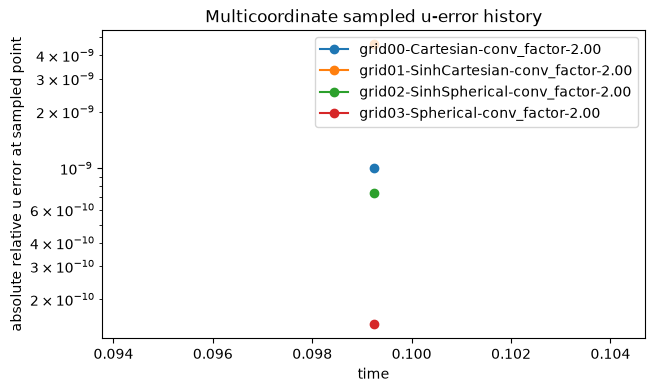

In [18]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 4))
for diagnostic, rows in diagnostic_rows.items():
    positive_rows = [row for row in rows if abs(row[1]) > 0.0]
    times = [row[0] for row in positive_rows]
    errors = [abs(row[1]) for row in positive_rows]
    label = diagnostic.stem.replace("out0d-", "")
    plt.plot(times, errors, marker="o", label=label)
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("absolute relative u error at sampled point")
plt.title("Multicoordinate sampled u-error history")
plt.legend()
plt.show()

The coordinate catalog, full inventory, RHS-source metadata, shared executable,
diagnostic table, and plot together show one generated project running the same
wave problem across several coordinate systems.

# What next?
### [Back to [top](#Table-of-Contents)]

- [BHaH Project Anatomy](../5-infrastructures/bhah_project_anatomy.ipynb)
- [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)
- [GeneralRFM and Fisheye Coordinates](../4-curvilinear/generalrfm_and_fisheye.ipynb)